In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('TaiwaneseData.csv')

# Calculate correlation matrix
corr_matrix = df.corr()

# Visualize
plt.figure(figsize=(16, 14), dpi=600)
sns.heatmap(corr_matrix, 
            annot=False,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.3,
            linecolor='white',
            cbar_kws={"shrink": 0.8, "label": "Corelation"})

plt.title('Corelation matrix', fontsize=18, pad=20, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# save
plt.savefig('correlation_matrix.png', dpi=600, bbox_inches='tight')
plt.show()


In [2]:
# Most correlated pairs
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_upper = corr_matrix.where(mask)

correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        correlations.append({
            'Variable 1': corr_matrix.columns[i],
            'Variable 2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

# DataFrame sorted by absolute correlation
corr_df = pd.DataFrame(correlations)
corr_df['Correlation_abs'] = corr_df['Correlation'].abs()
corr_df_sorted = corr_df.sort_values('Correlation_abs', ascending=False)

print("\n" + "="*80)
print("TOP 20 MOST CORRELATED VARIABLE PAIRS:")
print("="*80)
print(corr_df_sorted[['Variable 1', 'Variable 2', 'Correlation']].head(20).to_string(index=False))

print("\n" + "="*80)
print("TOP 10 STRONGEST POSITIVE CORRELATIONS:")
print("="*80)
positive_corr = corr_df_sorted[corr_df_sorted['Correlation'] > 0].head(10)
print(positive_corr[['Variable 1', 'Variable 2', 'Correlation']].to_string(index=False))

print("\n" + "="*80)
print("TOP 10 STRONGEST NEGATIVE CORRELATIONS:")
print("="*80)
negative_corr = corr_df_sorted[corr_df_sorted['Correlation'] < 0].head(10)
print(negative_corr[['Variable 1', 'Variable 2', 'Correlation']].to_string(index=False))

# Save to CSV file
corr_df_sorted[['Variable 1', 'Variable 2', 'Correlation']].to_csv('correlation_sorted.csv', index=False, encoding='utf-8-sig')



TOP 20 MOST CORRELATED VARIABLE PAIRS:
                                              Variable 1                                         Variable 2  Correlation
                           Current Liabilities/Liability                     Current Liability to Liability     1.000000
                              Current Liabilities/Equity                        Current Liability to Equity     1.000000
                                            Debt ratio %                                   Net worth/Assets    -1.000000
                                  Operating Gross Margin                              Gross Profit to Sales     1.000000
                                 Net Value Per Share (A)                            Net Value Per Share (C)     0.999837
                                  Operating Gross Margin                        Realized Sales Gross Margin     0.999518
                             Realized Sales Gross Margin                              Gross Profit to Sales     0

In [3]:
# Check the target column ('Bankrupt?' - column 0)
target_col = 'Bankrupt?'
print("Class Distribution:")
print(df[target_col].value_counts(normalize=True))

# Check for missing values
if df.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected.")
else:
    print("\nData is clean of missing values.")

Class Distribution:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

Data is clean of missing values.


Searching for best parameters...
Best Parameters found: {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}

--- Logistic Regression Report (Threshold 0.7) ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1320
           1       0.30      0.61      0.40        44

    accuracy                           0.94      1364
   macro avg       0.64      0.78      0.68      1364
weighted avg       0.96      0.94      0.95      1364

--- ROC-AUC Score: 0.8882 ---


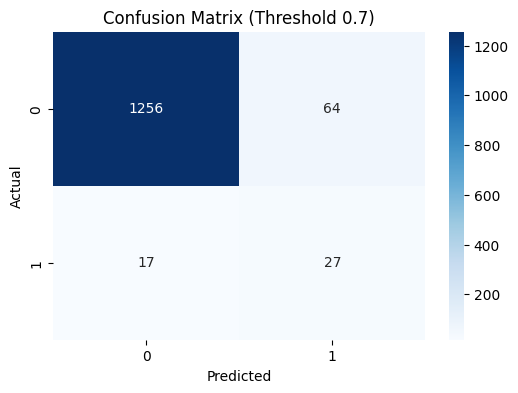

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


# Preprocessing: Remove Highly Correlated Features
# ---------------------------------------------------------
# We drop features with >0.95 correlation to help the linear model converge
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df_reduced = df.drop(to_drop, axis=1)

X = df_reduced.drop(target_col, axis=1)
y = df_reduced[target_col]

# 3. Stratified Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scaling (StandardScaler)
# ---------------------------------------------------------
# Linear models (Logistic Regression) absolutely require scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Training with Hyperparameter Optimization
# ---------------------------------------------------------
# We use GridSearchCV to find the best regularization strength (C)
# 'class_weight': 'balanced' automatically handles the 97% vs 3% imbalance
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  # Smaller C = Stronger Regularization
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

print("Searching for best parameters...")
grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print(f"Best Parameters found: {grid.best_params_}")

# 6. Evaluation
# ---------------------------------------------------------
# Get probabilities
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# THRESHOLD TUNING:
# Standard threshold is 0.5.
# Because the model is 'balanced', it might be too aggressive.
# We can raise the threshold to reduce False Positives.
threshold = 0.7 
y_pred = (y_prob >= threshold).astype(int)

print(f"\n--- Logistic Regression Report (Threshold {threshold}) ---")
print(classification_report(y_test, y_pred))

print(f"--- ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f} ---")

# Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Threshold {threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


# Preprocessing: Remove Highly Correlated Features
# ---------------------------------------------------------
# Calculate correlation matrix (absolute values)
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Dropping {len(to_drop)} correlated features...")
df_reduced = df.drop(to_drop, axis=1)

# Define X (features) and y (target)
X = df_reduced.drop(target_col, axis=1)
y = df_reduced[target_col]

# Stratified Train-Test Split
# ---------------------------------------------------------
# We use stratify=y to maintain the 97% vs 3% ratio in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalization (StandardScaler) - CRITICAL STEP
# ---------------------------------------------------------
scaler = StandardScaler()

# Fit only on Training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform Test data using the scaler trained on Train data
X_test_scaled = scaler.transform(X_test)

# Oversampling (SMOTE) - ONLY on Training Data
# ---------------------------------------------------------
print(f"Original training set shape: {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced training set shape: {y_train_balanced.value_counts().to_dict()}")

# Build and Train XGB Model
model_xgb = XGBClassifier(random_state=42, verbosity=0)
model_xgb.fit(X_train, y_train)

# Predict
y_pred = model_xgb.predict(X_test)
y_prob = model_xgb.predict_proba(X_test)[:, 1]


print("\nTraining Neural Network...")
model_xgb.fit(X_train_balanced, y_train_balanced)

# Evaluation
# ---------------------------------------------------------
# Get probabilities for ROC-AUC
y_prob = model_xgb.predict_proba(X_test_scaled)[:, 1]

# Custom Threshold Tuning (Standard is 0.5, but 0.2 is often safer for bankruptcy)
threshold = 0.5 
y_pred = (y_prob >= threshold).astype(int)

print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"--- ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f} ---")

# Simple text-based confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nConfusion Matrix:\nTrue Negatives: {tn}\nFalse Positives: {fp}\nFalse Negatives: {fn}\nTrue Positives (Caught Bankruptcies): {tp}")

Dropping 16 correlated features...
Original training set shape: {0: 5279, 1: 176}
Balanced training set shape: {0: 5279, 1: 5279}

Training Neural Network...

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1320
           1       0.52      0.57      0.54        44

    accuracy                           0.97      1364
   macro avg       0.75      0.78      0.76      1364
weighted avg       0.97      0.97      0.97      1364

--- ROC-AUC Score: 0.9453 ---

Confusion Matrix:
True Negatives: 1297
False Positives: 23
False Negatives: 19
True Positives (Caught Bankruptcies): 25


In [6]:
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

#XGBOOST UPGRADED

# Preprocessing: Remove Highly Correlated Features
# ---------------------------------------------------------
# Calculate correlation matrix (absolute values)
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Dropping {len(to_drop)} correlated features...")
df_reduced = df.drop(to_drop, axis=1)

# Define X (features) and y (target)
X = df_reduced.drop(target_col, axis=1)
y = df_reduced[target_col]

# Stratified Train-Test Split
# ---------------------------------------------------------
# We use stratify=y to maintain the 97% vs 3% ratio in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalization (StandardScaler) - CRITICAL STEP
# ---------------------------------------------------------
scaler = StandardScaler()

# Fit only on Training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform Test data using the scaler trained on Train data
X_test_scaled = scaler.transform(X_test)

# Oversampling (SMOTE) - ONLY on Training Data
# ---------------------------------------------------------
print(f"Original training set shape: {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=42, sampling_strategy = 0.5) # test auto saampling_strategy?
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print(f"Balanced training set shape: {y_train_balanced.value_counts().to_dict()}")

# Build and Train XGB Model
# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    # Tree parameters
    max_depth=6,                    # Deeper trees for complex patterns
    min_child_weight=3,             # Prevent overfitting on minority class
    
    # Boosting parameters
    n_estimators=500,               # More trees for better learning
    learning_rate=0.05,             # Lower learning rate with more estimators
    
    # Sampling parameters
    subsample=0.8,                  # Row sampling to prevent overfitting
    colsample_bytree=0.8,           # Column sampling per tree
    colsample_bylevel=0.8,          # Column sampling per level
    
    # Regularization
    gamma=1,                        # Minimum loss reduction for split
    reg_alpha=0.5,                  # L1 regularization
    reg_lambda=2,                   # L2 regularization
    
    # Class imbalance handling
    scale_pos_weight=scale_pos_weight,  # Weight for minority class
    
    # Other parameters
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    verbosity=0,
    use_label_encoder=False,
    early_stopping_rounds=50
)
# Train with early stopping
model_xgb.fit(
    X_train_balanced, 
    y_train_balanced,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)


# Prediction and Optimal Threshold Selection
# ---------------------------------------------------------
y_prob = model_xgb.predict_proba(X_test_scaled)[:, 1]

# Find optimal threshold using Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

print(f"\nOptimal Threshold: {optimal_threshold:.3f}")

# Apply optimal threshold
y_pred = (y_prob >= optimal_threshold).astype(int)

# Evaluation
# ---------------------------------------------------------
print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

print(f"\n--- ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f} ---")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nConfusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn} (Missed Bankruptcies)")
print(f"True Positives: {tp} (Caught Bankruptcies)")

# Additional Metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

# Feature Importance
# ---------------------------------------------------------
print("\n--- Top 10 Most Important Features ---")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance.to_string(index=False))

Dropping 16 correlated features...
Original training set shape: {0: 5279, 1: 176}
Balanced training set shape: {0: 5279, 1: 2639}

Optimal Threshold: 0.885

--- Final Classification Report ---
              precision    recall  f1-score   support

           0     0.9870    0.9765    0.9817      1320
           1     0.4655    0.6136    0.5294        44

    accuracy                         0.9648      1364
   macro avg     0.7263    0.7951    0.7556      1364
weighted avg     0.9702    0.9648    0.9671      1364


--- ROC-AUC Score: 0.9336 ---

Confusion Matrix:
True Negatives: 1289
False Positives: 31
False Negatives: 17 (Missed Bankruptcies)
True Positives: 27 (Caught Bankruptcies)

Sensitivity (Recall): 0.6136
Specificity: 0.9765

--- Top 10 Most Important Features ---
                                                 feature  importance
                       Retained Earnings to Total Assets    0.188930
                 Persistent EPS in the Last Four Seasons    0.091351
         

In [12]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, 
                             precision_recall_curve, make_scorer, f1_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# Preprocessing: Remove Highly Correlated Features
# ---------------------------------------------------------
print("Step 1: Removing correlated features...")
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Dropping {len(to_drop)} correlated features: {to_drop[:5]}...")
df_reduced = df.drop(to_drop, axis=1)

# Define X (features) and y (target)
X = df_reduced.drop(target_col, axis=1)
y = df_reduced[target_col]

print(f"Final feature count: {X.shape[1]}")
print(f"Class distribution: {y.value_counts().to_dict()}")

# Stratified Train-Test Split
# ---------------------------------------------------------
print("\nStep 2: Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalization (StandardScaler)
# ---------------------------------------------------------
print("Step 3: Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Oversampling (SMOTE) - ONLY on Training Data
# ---------------------------------------------------------
print("\nStep 4: Applying SMOTE...")
print(f"Original training set: {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print(f"Balanced training set: {pd.Series(y_train_balanced).value_counts().to_dict()}")

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Randomized Search for Hyperparameter Tuning
# ---------------------------------------------------------
print("\n" + "="*70)
print("Step 5: Running Randomized Search...")
print("="*70)

# Define parameter distribution
param_dist = {
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'n_estimators': [300, 400, 500, 600, 700],
    'min_child_weight': [1, 2, 3, 4, 5],
    'gamma': [0, 0.25, 0.5, 1.0],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 2, 3]
}

# Base model
base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    verbosity=0,
    use_label_encoder=False
)

# Randomized search with cross-validation
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=500,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0, # Silent
    return_train_score=True,
    random_state=42
)

# Fit randomized search
random_search.fit(X_train_balanced, y_train_balanced)

# Display results
print("\n" + "="*70)
print("SEARCH RESULTS")
print("="*70)
print(f"Best ROC-AUC Score (CV): {random_search.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

# Get best model
model_xgb = random_search.best_estimator_

# Retrain best model with early stopping on full training set
print("\nStep 6: Retraining best model with early stopping...")
model_xgb.fit(
    X_train_balanced, 
    y_train_balanced,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

# Prediction and Optimal Threshold Selection
# ---------------------------------------------------------
print("\nStep 7: Making predictions and finding optimal threshold...")
y_prob = model_xgb.predict_proba(X_test_scaled)[:, 1]

# Find optimal threshold using Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"Max F1-Score at threshold: {f1_scores[optimal_idx]:.4f}")

# Apply optimal threshold
y_pred = (y_prob >= optimal_threshold).astype(int)

# Evaluation
# ---------------------------------------------------------
print("\n" + "="*70)
print("FINAL MODEL EVALUATION")
print("="*70)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

print(f"\n--- ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f} ---")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\n--- Confusion Matrix ---")
print(f"True Negatives (Correct Non-Bankruptcy): {tn}")
print(f"False Positives (False Alarms): {fp}")
print(f"False Negatives (MISSED Bankruptcies): {fn}")
print(f"True Positives (CAUGHT Bankruptcies): {tp}")

# Additional Metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\n--- Key Metrics ---")
print(f"Sensitivity/Recall (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"Precision (Positive Predictive Value): {precision:.4f}")
print(f"Negative Predictive Value: {npv:.4f}")

# Feature Importance
# ---------------------------------------------------------
print("\n" + "="*70)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*70)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)
print(feature_importance.to_string(index=False))

# Performance at different thresholds
print("\n" + "="*70)
print("PERFORMANCE AT DIFFERENT THRESHOLDS")
print("="*70)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_temp = (y_prob >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_temp).ravel()
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    print(f"Threshold {thresh:.1f}: Recall={recall_t:.3f}, Precision={precision_t:.3f}, Caught={tp_t}, Missed={fn_t}")

print("\n" + "="*70)
print("MODEL TRAINING COMPLETE!")
print("="*70)

Step 1: Removing correlated features...
Dropping 16 correlated features: [' ROA(B) before interest and depreciation after tax', ' Realized Sales Gross Margin', ' After-tax net Interest Rate', ' Continuous interest rate (after tax)', ' Net Value Per Share (A)']...
Final feature count: 79
Class distribution: {0: 6599, 1: 220}

Step 2: Splitting data...
Step 3: Scaling features...

Step 4: Applying SMOTE...
Original training set: {0: 5279, 1: 176}
Balanced training set: {0: 5279, 1: 2639}
Scale pos weight: 29.99

Step 5: Running Randomized Search...

SEARCH RESULTS
Best ROC-AUC Score (CV): 0.9986

Best Parameters:
  subsample: 0.9
  reg_lambda: 2
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 1
  max_depth: 6
  learning_rate: 0.1
  gamma: 0
  colsample_bytree: 0.7

Step 6: Retraining best model with early stopping...

SEARCH RESULTS
Best ROC-AUC Score (CV): 0.9986

Best Parameters:
  subsample: 0.9
  reg_lambda: 2
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 1
  max_dept